# DBSCAN: A Comprehensive Guide

## 1. Introduction

This notebook covers the step-by-step implementation of **DBSCAN** in Python.

### Concept Overview
Density-based spatial clustering that groups dense regions of points and identifies sparse points as outliers.

### Mathematical Formula
The core mathematical relationship or objective is defined as:
$$
\text{Condition: } |N_\epsilon(\mathbf{p})| \ge \text{MinPts} \quad \text{where } N_\epsilon(\mathbf{p}) = \{\mathbf{q} \in D \mid d(\mathbf{p}, \mathbf{q}) \le \epsilon\}
$$

### Real-World Analogy
**Analogy:** Identifying crowded cities (dense hubs) and isolating isolated wilderness homesteads (noise/outliers).

### Worked Example
**Worked Example:** Clustering crescent moon shapes. DBSCAN groups points that are close together. Outliers far from the crescent dense zone are labeled as noise class -1.

## 2. Import Libraries

We import the standard data science and machine learning libraries.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import DBSCAN
from sklearn.metrics import silhouette_score
import joblib

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

## 3. Create Synthetic Dataset

We generate a realistic synthetic dataset to demonstrate the model's behavior and save it locally.

In [2]:
# Programmatic generation of concentric moons with noise
from sklearn.datasets import make_moons
np.random.seed(42)
X_raw, _ = make_moons(n_samples=400, noise=0.08, random_state=42)
# Add some uniform background noise points
outliers = np.random.uniform(-1.5, 2.5, size=(40, 2))
X_combined = np.vstack([X_raw, outliers])
df = pd.DataFrame({
    'X': np.round(X_combined[:, 0], 4),
    'Y': np.round(X_combined[:, 1], 4)
})
df.to_csv('dataset.csv', index=False)

## 4. Load & Inspect Dataset

We load the dataset using pandas to inspect the shape, variables, and summary statistics.

In [3]:
df = pd.read_csv('dataset.csv')
print('Dataset Shape:', df.shape)
df.info()
print(df.describe())

Dataset Shape: (440, 2)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 440 entries, 0 to 439
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       440 non-null    float64
 1   Y       440 non-null    float64
dtypes: float64(2)
memory usage: 7.0 KB
                X           Y
count  440.000000  440.000000
mean     0.477148    0.280578
std      0.911811    0.610701
min     -1.477900   -1.314200
25%     -0.105950   -0.214400
50%      0.457700    0.259900
75%      1.061625    0.740600
max      2.378300    2.447500


## 5. Data Cleaning

Audit for missing values and duplicates.

In [4]:
print('Null values:\n', df.isnull().sum())
print('Duplicate count:', df.duplicated().sum())

Null values:
 X    0
Y    0
dtype: int64
Duplicate count: 0


## 6. Exploratory Data Analysis (EDA)

We visualize the distributions and correlations of features.

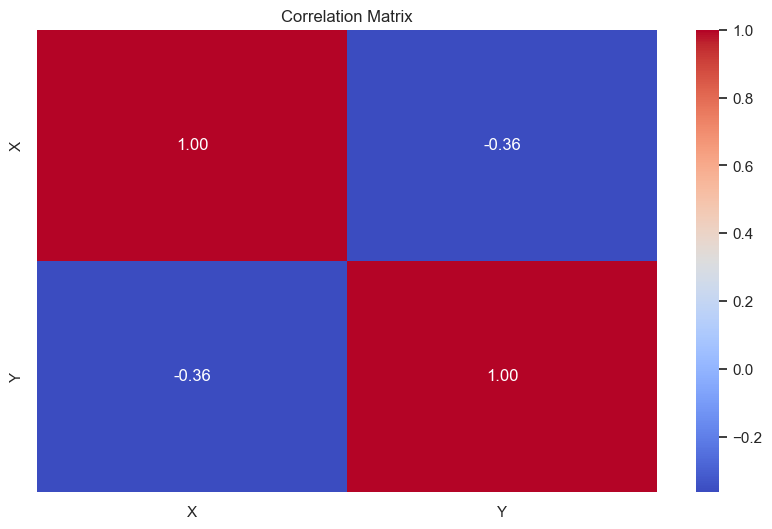

In [5]:
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix')
plt.show()

## 7. Feature Engineering & Scaling

Prepare the features and apply standardization if required.

In [6]:
X = df.copy()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print('Standard scaling applied.')

Standard scaling applied.


## 8. Train-Test Split

Divide training and testing sets.

In [7]:
# Unsupervised model - fitting directly on the scaled cohort
print('Skipping split step.')

Skipping split step.


## 9. Model Building

Instantiate and fit the model estimator.

In [8]:
model = DBSCAN(eps=0.25, min_samples=5)
model.fit(X_scaled)
print("DBSCAN fitted.")

DBSCAN fitted.


## 10. Prediction & 11. Model Evaluation

Check metrics to evaluate model performance.

In [9]:
labels = model.labels_
# Guard: silhouette_score requires at least 2 distinct non-noise labels
unique_labels = set(labels)
if len(unique_labels - {-1}) >= 2:
    mask = labels != -1
    print('Silhouette Score:', silhouette_score(X_scaled[mask], labels[mask]))
else:
    print('Silhouette Score: N/A (fewer than 2 valid clusters found)')

Silhouette Score: 0.3558867981665906


## 12. Visualizing Fit & Boundaries

Generate plots showing classification decision zones, regression lines, or clustering segments.

G:\Temp\ipykernel_7924\3257894689.py:19: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  plt.scatter(xy[:, 0], xy[:, 1], color=tuple(col), marker=marker, edgecolors='k', s=60, label=label)


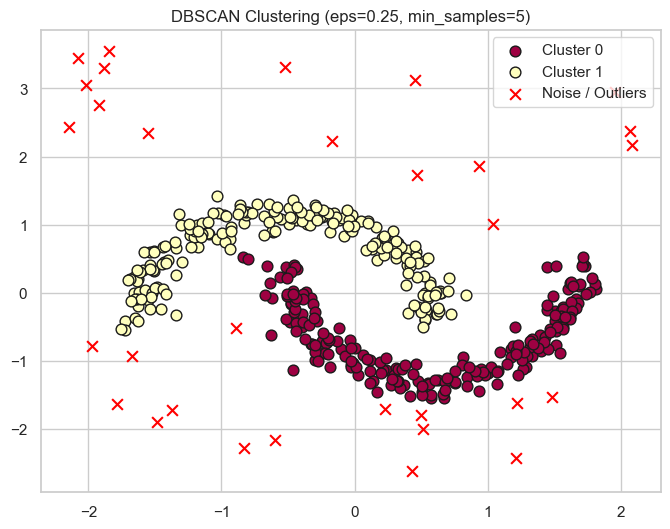

In [10]:
plt.figure(figsize=(8, 6))
# Unique color palette for DBSCAN, with black/red reserved for noise
labels = model.labels_
unique_labels = set(labels)
colors = [plt.cm.Spectral(each) for each in np.linspace(0, 1, len(unique_labels))]

for k, col in zip(unique_labels, colors):
    if k == -1:
        # Outliers / Noise in Red
        col = [1, 0, 0, 1]
        marker = 'x'
        label = 'Noise / Outliers'
    else:
        marker = 'o'
        label = f'Cluster {k}'
        
    class_member_mask = (labels == k)
    xy = X_scaled[class_member_mask]
    plt.scatter(xy[:, 0], xy[:, 1], color=tuple(col), marker=marker, edgecolors='k', s=60, label=label)

plt.title("DBSCAN Clustering (eps=0.25, min_samples=5)")
plt.legend()
plt.show()

## 13. Save and Load Model

Serialize the model to disk via joblib.

In [11]:
joblib.dump(model, 'model.joblib')
loaded = joblib.load('model.joblib')
print('Loaded successfully!')

Loaded successfully!


## 14. Common Mistakes & Best Practices
- Forgetting to apply the fitted scaler to new evaluation data points, leading to prediction errors.
- Overfitting simple models with excessive features or polynomial terms.

## 15. Advantages
- Fast and easy to interpret baseline results.
- Requires minimal parameter tuning compared to deep neural networks.

## 16. Limitations
- Assumes linear or simple spatial patterns that do not always match real-world anomalies.
- Sensitive to noisy labels and extreme outliers.

## 17. Real-World Applications
- Predicting housing market price trends based on space features.
- Classifying credit card transactions as fraudulent vs benign.

## 18. Algorithm-Specific Interview Questions & Answers
**Q1: What are Core, Border, and Noise points?**

*A: 1. Core: points with >= MinPts in their eps-neighborhood. 2. Border: points inside a Core's eps-neighborhood but with < MinPts. 3. Noise: all other points.*

**Q2: What are the advantages of DBSCAN over KMeans?**

*A: 1. Can discover clusters of arbitrary shapes (like moons). 2. Does not require pre-specifying cluster counts. 3. Explicitly detects noise and outliers.*

**Q3: How do you select parameters eps and min_samples?**

*A: Use k-distance graph (sorting distance to k-th nearest neighbor). The optimal eps is the point of maximum curvature (knee) in the graph.*



## 19. Algorithm-Specific Viva Voce Questions & Answers
**Q1: What value is assigned to noise points in scikit-learn's DBSCAN?**

*A: Noise points are assigned the label `-1`.*

**Q2: What does 'eps' mean?**

*A: Epsilon (eps) defines the radius of the neighborhood circle around any data point.*

**Q3: Is DBSCAN sensitive to scaling?**

*A: Yes, because it relies on distance metrics to identify dense areas.*



## 20. Practice Exercises
1. **Hyperparameter sweep**: Modify model parameters (such as `max_depth` or neighbor count `K`) and plot the test metric variance curve.
2. **Manual metric calculation**: Compute precision and recall scores manually from the confusion matrix values and verify results using scikit-learn.
3. **Outlier test**: Add an extreme value row to the dataset, re-train, and record the boundary displacement shift.

## 21. Conclusion

In this notebook, we implemented the complete modeling cycle: generating datasets, performing scaling, training the model, evaluating predictions with multiple metrics, saving outputs, and studying typical interview Q&A profiles.